Name: Sahil Suresh Ghogare

Roll no.: 23102A0061

Branch / Div: BE CMPN A

R_EXP_6

**Installing required packages & Importing Libraries**

In [1]:
install.packages("palmerpenguins")
install.packages("ggplot2")
install.packages("dplyr")
install.packages("moments")
install.packages("car")

library(palmerpenguins)
library(ggplot2)
library(dplyr)
library(moments)
library(car)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘cowplot’, ‘Deriv’, ‘forecast’, ‘rbibutils’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’



Attaching package: ‘palmerpenguins’


The following objects are masked from ‘package:datasets’:

    penguins, penguins_raw



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are mas

**Loading the dataset**

In [2]:
data("penguins")

head(penguins)

str(penguins)

dim(penguins)

colnames(penguins)

species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>
Adelie,Torgersen,39.1,18.7,181,3750,male,2007
Adelie,Torgersen,39.5,17.4,186,3800,female,2007
Adelie,Torgersen,40.3,18.0,195,3250,female,2007
Adelie,Torgersen,NA,NA,NA,NA,NA,2007
Adelie,Torgersen,36.7,19.3,193,3450,female,2007
Adelie,Torgersen,39.3,20.6,190,3650,male,2007


tibble [344 × 8] (S3: tbl_df/tbl/data.frame)
 $ species          : Factor w/ 3 levels "Adelie","Chinstrap",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ island           : Factor w/ 3 levels "Biscoe","Dream",..: 3 3 3 3 3 3 3 3 3 3 ...
 $ bill_length_mm   : num [1:344] 39.1 39.5 40.3 NA 36.7 39.3 38.9 39.2 34.1 42 ...
 $ bill_depth_mm    : num [1:344] 18.7 17.4 18 NA 19.3 20.6 17.8 19.6 18.1 20.2 ...
 $ flipper_length_mm: int [1:344] 181 186 195 NA 193 190 181 195 193 190 ...
 $ body_mass_g      : int [1:344] 3750 3800 3250 NA 3450 3650 3625 4675 3475 4250 ...
 $ sex              : Factor w/ 2 levels "female","male": 2 1 1 NA 1 2 1 2 NA NA ...
 $ year             : int [1:344] 2007 2007 2007 2007 2007 2007 2007 2007 2007 2007 ...


[1] 344   8

[1] "species"           "island"            "bill_length_mm"   
[4] "bill_depth_mm"     "flipper_length_mm" "body_mass_g"      
[7] "sex"               "year"

**Data Cleaning**

In [3]:
colSums(is.na(penguins))

penguins_clean <- na.omit(penguins)

head(penguins_clean)

dim(penguins_clean)

species            island    bill_length_mm     bill_depth_mm 
                0                 0                 2                 2 
flipper_length_mm       body_mass_g               sex              year 
                2                 2                11                 0

species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>
Adelie,Torgersen,39.1,18.7,181,3750,male,2007
Adelie,Torgersen,39.5,17.4,186,3800,female,2007
Adelie,Torgersen,40.3,18.0,195,3250,female,2007
Adelie,Torgersen,36.7,19.3,193,3450,female,2007
Adelie,Torgersen,39.3,20.6,190,3650,male,2007
Adelie,Torgersen,38.9,17.8,181,3625,female,2007


[1] 333   8

**Descriptive Statistics of Body Mass**

In [4]:
body_mass <- penguins_clean$body_mass_g

cat("Mean:", mean(body_mass), "\n")
cat("Median:", median(body_mass), "\n")
cat("Minimum:", min(body_mass), "\n")
cat("Maximum:", max(body_mass), "\n")
cat("Variance:", var(body_mass), "\n")
cat("Standard Deviation:", sd(body_mass), "\n")
cat("Q1:", quantile(body_mass, 0.25), "\n")
cat("Q3:", quantile(body_mass, 0.75), "\n")
cat("IQR:", IQR(body_mass), "\n")
cat("Skewness:", skewness(body_mass), "\n")
cat("Kurtosis:", kurtosis(body_mass), "\n")

Mean: 4207.057 
Median: 4050 
Minimum: 2700 
Maximum: 6300 
Variance: 648372.5 
Standard Deviation: 805.2158 
Q1: 3550 
Q3: 4775 
IQR: 1225 
Skewness: 0.4701162 
Kurtosis: 2.259514 


**Species-wise Descriptive Statistics**

In [5]:
species_summary <- penguins_clean %>%
  group_by(species) %>%
  summarise(
    Count = n(),
    Mean = mean(body_mass_g),
    Median = median(body_mass_g),
    Minimum = min(body_mass_g),
    Maximum = max(body_mass_g),
    Variance = var(body_mass_g),
    SD = sd(body_mass_g),
    Q1 = quantile(body_mass_g, 0.25),
    Q3 = quantile(body_mass_g, 0.75),
    IQR = IQR(body_mass_g),
    Skewness = skewness(body_mass_g),
    Kurtosis = kurtosis(body_mass_g)
  )

print(species_summary)

# A tibble: 3 × 13
  species   Count  Mean Median Minimum Maximum Variance    SD    Q1    Q3   IQR
  <fct>     <int> <dbl>  <dbl>   <int>   <int>    <dbl> <dbl> <dbl> <dbl> <dbl>
1 Adelie      146 3706.   3700    2850    4775  210332.  459. 3362.  4000  638.
2 Chinstrap    68 3733.   3700    2700    4800  147713.  384. 3488.  3950  462.
3 Gentoo      119 5092.   5050    3950    6300  251478.  501. 4700   5500  800 
# ℹ 2 more variables: Skewness <dbl>, Kurtosis <dbl>


**Histogram and Density Plot**

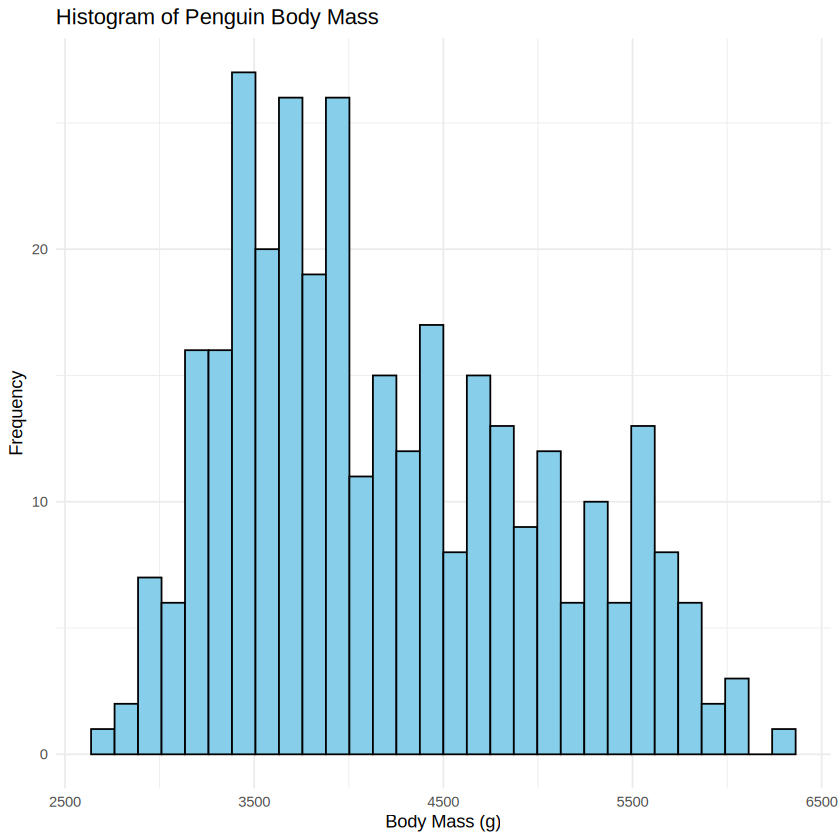

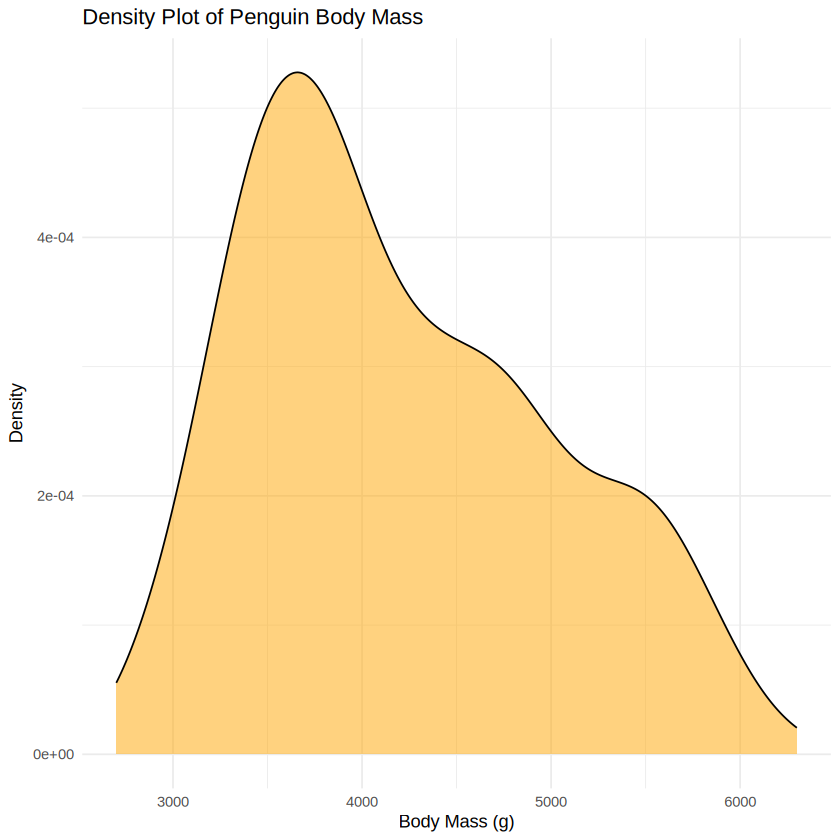

In [6]:
ggplot(penguins_clean, aes(x = body_mass_g)) +
  geom_histogram(
    bins = 30,
    fill = "skyblue",
    color = "black"
  ) +
  labs(
    title = "Histogram of Penguin Body Mass",
    x = "Body Mass (g)",
    y = "Frequency"
  ) +
  theme_minimal()

ggplot(penguins_clean, aes(x = body_mass_g)) +
  geom_density(
    fill = "orange",
    alpha = 0.5
  ) +
  labs(
    title = "Density Plot of Penguin Body Mass",
    x = "Body Mass (g)",
    y = "Density"
  ) +
  theme_minimal()

**Species-wise and Sex-wise Boxplots**

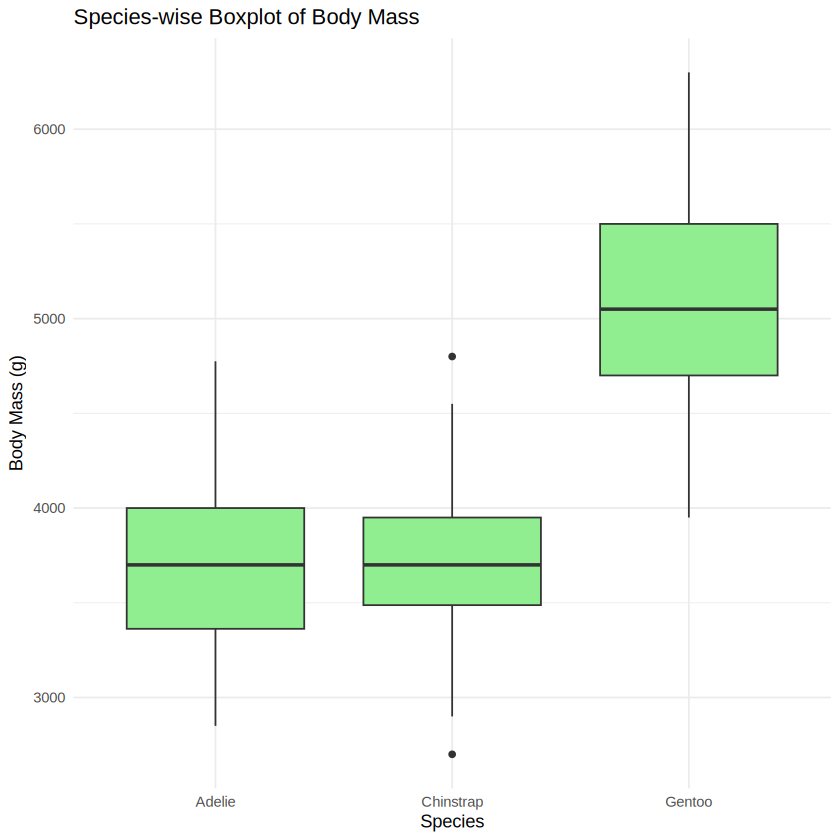

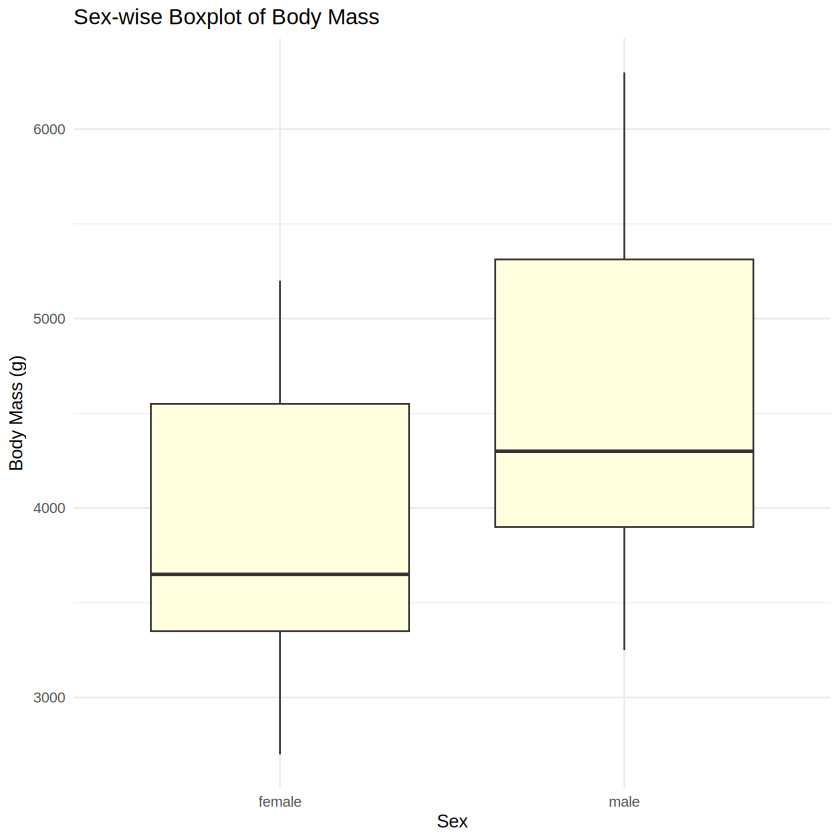

In [7]:
ggplot(penguins_clean, aes(x = species, y = body_mass_g)) +
  geom_boxplot(fill = "lightgreen") +
  labs(
    title = "Species-wise Boxplot of Body Mass",
    x = "Species",
    y = "Body Mass (g)"
  ) +
  theme_minimal()

ggplot(penguins_clean, aes(x = sex, y = body_mass_g)) +
  geom_boxplot(fill = "lightyellow") +
  labs(
    title = "Sex-wise Boxplot of Body Mass",
    x = "Sex",
    y = "Body Mass (g)"
  ) +
  theme_minimal()

**Hypothesis Testing: Prepare Male and Female Data**

In [8]:
male_mass <- penguins_clean %>%
  filter(sex == "male") %>%
  pull(body_mass_g)

female_mass <- penguins_clean %>%
  filter(sex == "female") %>%
  pull(body_mass_g)

cat("Male count:", length(male_mass), "\n")
cat("Female count:", length(female_mass), "\n")

cat("Male mean:", mean(male_mass), "\n")
cat("Female mean:", mean(female_mass), "\n")

Male count: 168 
Female count: 165 
Male mean: 4545.685 
Female mean: 3862.273 


**Normality Test and QQ Plots**

Male Shapiro-Wilk Test:

	Shapiro-Wilk normality test

data:  male_mass
W = 0.92504, p-value = 1.227e-07


Female Shapiro-Wilk Test:

	Shapiro-Wilk normality test

data:  female_mass
W = 0.91931, p-value = 6.155e-08



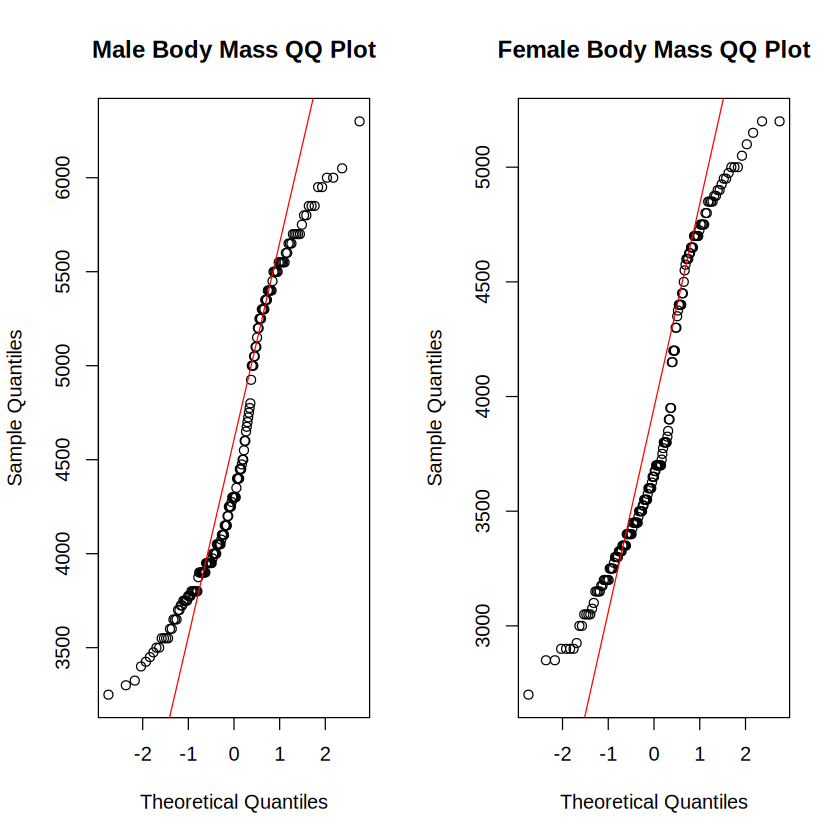

In [9]:
cat("Male Shapiro-Wilk Test:\n")
print(shapiro.test(male_mass))

cat("\nFemale Shapiro-Wilk Test:\n")
print(shapiro.test(female_mass))

par(mfrow = c(1, 2))

qqnorm(male_mass, main = "Male Body Mass QQ Plot")
qqline(male_mass, col = "red")

qqnorm(female_mass, main = "Female Body Mass QQ Plot")
qqline(female_mass, col = "red")

par(mfrow = c(1, 1))

**Independent Two-Sample t-Test**

In [10]:
t_test_result <- t.test(
  male_mass,
  female_mass,
  alternative = "two.sided",
  conf.level = 0.95
)

print(t_test_result)

cat("\n95% Confidence Interval:\n")
print(t_test_result$conf.int)

cat("\nP-value:", t_test_result$p.value, "\n")


	Welch Two Sample t-test

data:  male_mass and female_mass
t = 8.5545, df = 323.9, p-value = 4.794e-16
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 526.2453 840.5783
sample estimates:
mean of x mean of y 
 4545.685  3862.273 


95% Confidence Interval:
[1] 526.2453 840.5783
attr(,"conf.level")
[1] 0.95

P-value: 4.793891e-16 


**Cohen's d Effect Size**

In [11]:
n_male <- length(male_mass)
n_female <- length(female_mass)

sd_male <- sd(male_mass)
sd_female <- sd(female_mass)

pooled_sd <- sqrt(
  ((n_male - 1) * sd_male^2 +
   (n_female - 1) * sd_female^2) /
  (n_male + n_female - 2)
)

cohens_d <- (
  mean(male_mass) - mean(female_mass)
) / pooled_sd

cat("Pooled SD:", pooled_sd, "\n")
cat("Cohen's d:", cohens_d, "\n")
cat("Absolute Cohen's d:", abs(cohens_d), "\n")

Pooled SD: 729.9811 
Cohen's d: 0.9362048 
Absolute Cohen's d: 0.9362048 


**One-Way ANOVA and Levene's Test**

In [12]:
anova_model <- aov(
  body_mass_g ~ species,
  data = penguins_clean
)

cat("One-Way ANOVA:\n")
print(summary(anova_model))

cat("\nLevene's Test:\n")
print(
  leveneTest(
    body_mass_g ~ species,
    data = penguins_clean
  )
)

One-Way ANOVA:
             Df    Sum Sq  Mean Sq F value Pr(>F)    
species       2 145190219 72595110   341.9 <2e-16 ***
Residuals   330  70069447   212332                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Levene's Test:
Levene's Test for Homogeneity of Variance (center = median)
       Df F value   Pr(>F)   
group   2  5.1349 0.006367 **
      330                    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


**Tukey HSD and Kruskal-Wallis**

Tukey HSD:
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = body_mass_g ~ species, data = penguins_clean)

$species
                       diff       lwr       upr    p adj
Chinstrap-Adelie   26.92385 -132.3528  186.2005 0.916431
Gentoo-Adelie    1386.27259 1252.2897 1520.2554 0.000000
Gentoo-Chinstrap 1359.34874 1194.4304 1524.2671 0.000000


Kruskal-Wallis Test:

	Kruskal-Wallis rank sum test

data:  body_mass_g by species
Kruskal-Wallis chi-squared = 212.09, df = 2, p-value < 2.2e-16


ANOVA p-value: 3.744505e-81 
Kruskal-Wallis p-value: 8.836877e-47 


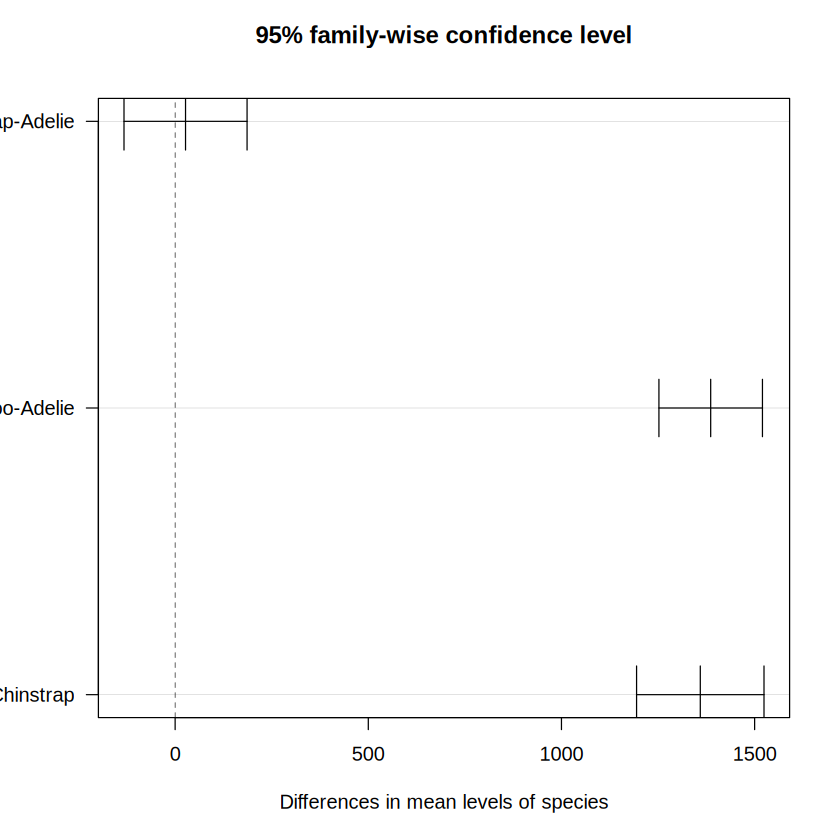

In [13]:
cat("Tukey HSD:\n")
tukey_result <- TukeyHSD(anova_model)
print(tukey_result)

plot(tukey_result, las = 1)

cat("\nKruskal-Wallis Test:\n")
kruskal_result <- kruskal.test(
  body_mass_g ~ species,
  data = penguins_clean
)

print(kruskal_result)

anova_p <- summary(anova_model)[[1]][["Pr(>F)"]][1]

cat("\nANOVA p-value:", anova_p, "\n")
cat("Kruskal-Wallis p-value:", kruskal_result$p.value, "\n")

**Two-Way ANOVA**

In [14]:
two_way_model <- aov(
  body_mass_g ~ species * sex,
  data = penguins_clean
)

summary(two_way_model)

             Df    Sum Sq  Mean Sq F value   Pr(>F)    
species       2 145190219 72595110 758.358  < 2e-16 ***
sex           1  37090262 37090262 387.460  < 2e-16 ***
species:sex   2   1676557   838278   8.757 0.000197 ***
Residuals   327  31302628    95727                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

**Interaction Plot**

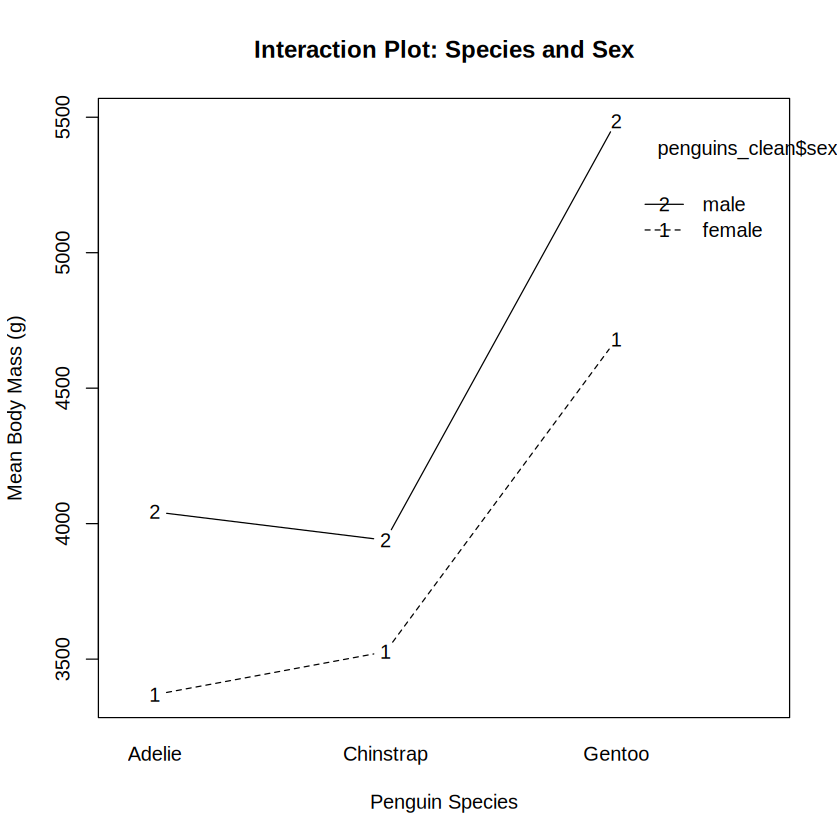

In [15]:
interaction.plot(
  x.factor = penguins_clean$species,
  trace.factor = penguins_clean$sex,
  response = penguins_clean$body_mass_g,
  fun = mean,
  type = "b",
  legend = TRUE,
  xlab = "Penguin Species",
  ylab = "Mean Body Mass (g)",
  main = "Interaction Plot: Species and Sex"
)

**Flipper Length Analysis**

Flipper Length Descriptive Statistics
Mean: 200.967 
Median: 197 
Minimum: 172 
Maximum: 231 
Variance: 196.4417 
Standard Deviation: 14.01577 
Q1: 190 
Q3: 213 
IQR: 23 
Skewness: 0.3585237 
Kurtosis: 2.035167 

Flipper Length ANOVA:
             Df Sum Sq Mean Sq F value Pr(>F)    
species       2  50526   25263   567.4 <2e-16 ***
Residuals   330  14693      45                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Flipper Length Tukey HSD:
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = flipper_length_mm ~ species, data = penguins_clean)

$species
                     diff       lwr       upr p adj
Chinstrap-Adelie  5.72079  3.414364  8.027215     0
Gentoo-Adelie    27.13255 25.192399 29.072709     0
Gentoo-Chinstrap 21.41176 19.023644 23.799885     0


Flipper Length Kruskal-Wallis:

	Kruskal-Wallis rank sum test

data:  flipper_length_mm by species
Kruskal-Wallis chi-squared = 237.35, df = 2, p-value < 

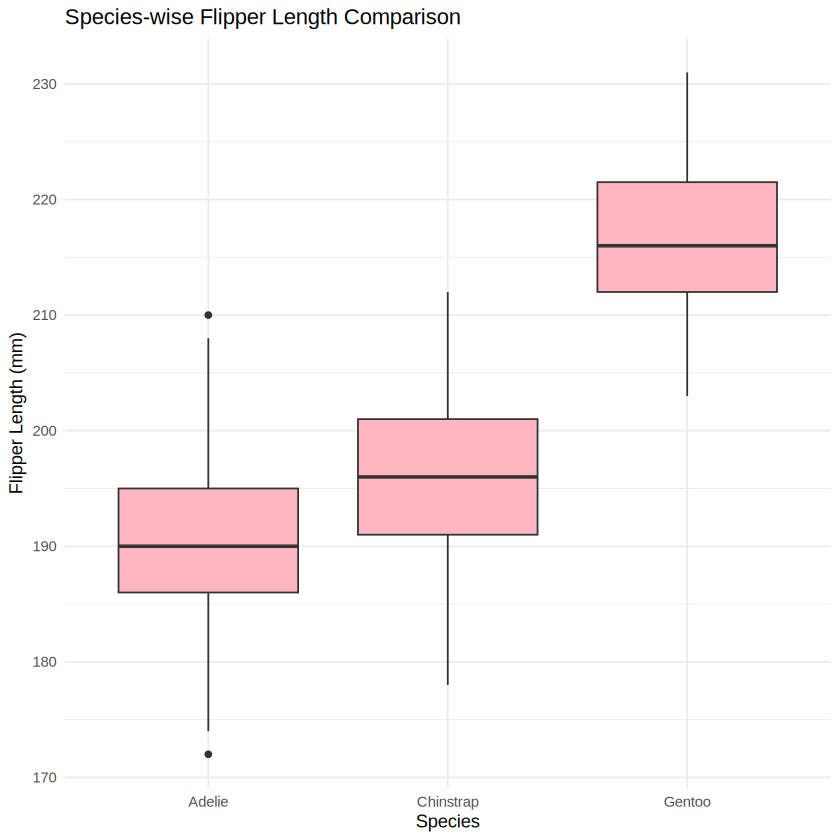

In [16]:
flipper <- penguins_clean$flipper_length_mm

cat("Flipper Length Descriptive Statistics\n")
cat("Mean:", mean(flipper), "\n")
cat("Median:", median(flipper), "\n")
cat("Minimum:", min(flipper), "\n")
cat("Maximum:", max(flipper), "\n")
cat("Variance:", var(flipper), "\n")
cat("Standard Deviation:", sd(flipper), "\n")
cat("Q1:", quantile(flipper, 0.25), "\n")
cat("Q3:", quantile(flipper, 0.75), "\n")
cat("IQR:", IQR(flipper), "\n")
cat("Skewness:", skewness(flipper), "\n")
cat("Kurtosis:", kurtosis(flipper), "\n")

ggplot(
  penguins_clean,
  aes(x = species, y = flipper_length_mm)
) +
  geom_boxplot(fill = "lightpink") +
  labs(
    title = "Species-wise Flipper Length Comparison",
    x = "Species",
    y = "Flipper Length (mm)"
  ) +
  theme_minimal()

flipper_anova <- aov(
  flipper_length_mm ~ species,
  data = penguins_clean
)

cat("\nFlipper Length ANOVA:\n")
print(summary(flipper_anova))

cat("\nFlipper Length Tukey HSD:\n")
print(TukeyHSD(flipper_anova))

cat("\nFlipper Length Kruskal-Wallis:\n")
print(
  kruskal.test(
    flipper_length_mm ~ species,
    data = penguins_clean
  )
)